In [1]:
#1.Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
#2. Cargar dataset
df = pd.read_csv("energia_data_limpio.csv")
df.head()

,Temperatura,Hora,Dia_Semana,Consumo_Energia
0,28.891805,1,1,401.990602
1,22.244071,2,2,334.846911
2,20.909006,3,3,326.926080
3,24.983128,4,4,383.016951
4,24.149077,5,5,388.748151


In [3]:
#3. Revisar y limpiar datos
df.info()
df.isnull().sum()
df = df.dropna()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Temperatura      10000 non-null  float64
 1   Hora             10000 non-null  int64  
 2   Dia_Semana       10000 non-null  int64  
 3   Consumo_Energia  10000 non-null  float64
dtypes: float64(2), int64(2)
memory usage: 312.6 KB


Index(['Temperatura', 'Hora', 'Dia_Semana', 'Consumo_Energia'], dtype='object')

In [4]:
#4. Separar variables
X = df[['Temperatura', 'Hora', 'Dia_Semana']]
y = df['Consumo_Energia']

In [5]:
#5. Dividir entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
#6. Entrenar modelo
modelo_energia = LinearRegression()
modelo_energia.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
#7. Hacer predicciones
y_pred = modelo_energia.predict(X_test)

In [8]:
#8. Evaluar con RMSE y R²
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"Coeficiente de determinación R²: {r2:.4f}")

RMSE: 20.7248
Coeficiente de determinación R²: 0.8968


In [9]:
#9. Coeficientes del modelo
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_energia.coef_
})

coeficientes

,Variable,Coeficiente
0,Temperatura,9.952866
1,Hora,5.019813
2,Dia_Semana,-3.031177


In [10]:
#10. Variable con mayor impacto
coeficientes["Impacto"] = coeficientes["Coeficiente"].abs()

coeficientes_ordenados = coeficientes.sort_values(
    by="Impacto", ascending=False
)

coeficientes_ordenados

,Variable,Coeficiente,Impacto
0,Temperatura,9.952866,9.952866
1,Hora,5.019813,5.019813
2,Dia_Semana,-3.031177,3.031177


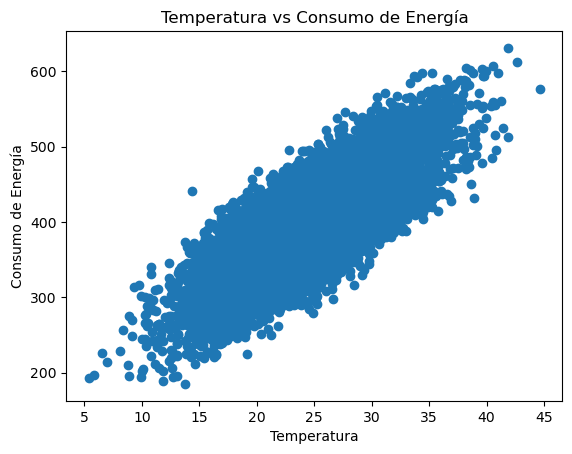

In [11]:
#11. Gráficas
plt.scatter(df['Temperatura'], df['Consumo_Energia'])
plt.xlabel("Temperatura")
plt.ylabel("Consumo de Energía")
plt.title("Temperatura vs Consumo de Energía")
plt.show()

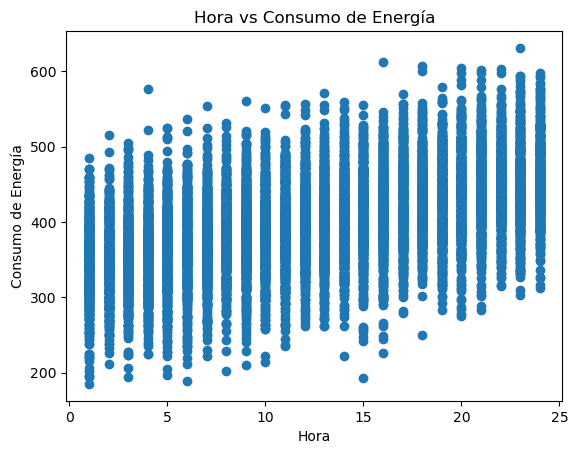

In [12]:
plt.scatter(df['Hora'], df['Consumo_Energia'])
plt.xlabel("Hora")
plt.ylabel("Consumo de Energía")
plt.title("Hora vs Consumo de Energía")
plt.show()

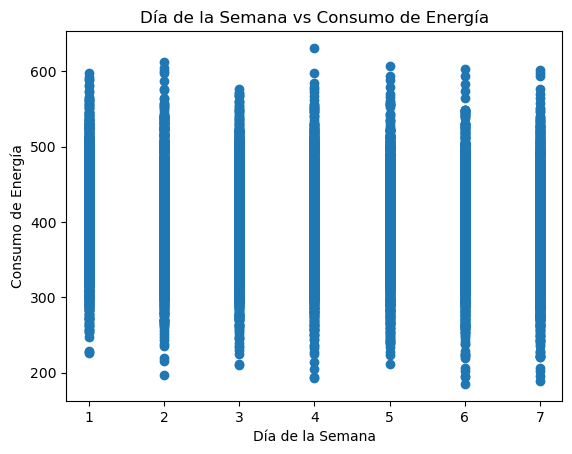

In [13]:
plt.scatter(df['Dia_Semana'], df['Consumo_Energia'])
plt.xlabel("Día de la Semana")
plt.ylabel("Consumo de Energía")
plt.title("Día de la Semana vs Consumo de Energía")
plt.show()

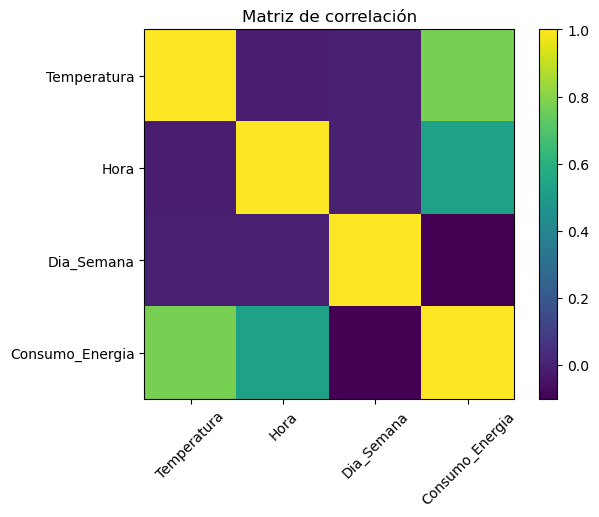

,Temperatura,Hora,Dia_Semana,Consumo_Energia
Temperatura,1.000000,-0.018589,-0.006855,0.771915
Hora,-0.018589,1.000000,-0.000051,0.528963
Dia_Semana,-0.006855,-0.000051,1.000000,-0.102187
Consumo_Energia,0.771915,0.528963,-0.102187,1.000000


In [14]:
#12. Matriz de correlación
correlacion = df.corr(numeric_only=True)

plt.imshow(correlacion)
plt.colorbar()
plt.xticks(range(len(correlacion.columns)), correlacion.columns, rotation=45)
plt.yticks(range(len(correlacion.columns)), correlacion.columns)
plt.title("Matriz de correlación")
plt.show()

correlacion

In [15]:
#13. Predicción manual
temperatura = float(input("Ingrese la temperatura en °C: "))
hora = int(input("Ingrese la hora del día 1-24: "))
dia_semana = int(input("Ingrese el día de la semana 1=Lunes, 7=Domingo: "))

nuevo_registro = pd.DataFrame({
    "Temperatura": [temperatura],
    "Hora": [hora],
    "Dia_Semana": [dia_semana]
})

prediccion = modelo_energia.predict(nuevo_registro)

print(f"Consumo de energía estimado: {prediccion[0]:.2f} kWh")

Ingrese la temperatura en °C:  2
Ingrese la hora del día 1-24:  1
Ingrese el día de la semana 1=Lunes, 7=Domingo:  5


Consumo de energía estimado: 111.06 kWh


In [16]:
# ============================================================
# EXPORTAR MODELO Y VARIABLES EN UN SOLO ARCHIVO (ENERGÍA)
# ============================================================

import joblib
import os

# Crear carpeta si no existe
os.makedirs("modelos", exist_ok=True)

paquete_energia = {
    "modelo": modelo_energia,  # tu modelo entrenado (base o polinómico)
    "variables": ["Temperatura", "Hora", "Dia_Semana"],
    "variable_objetivo": "Consumo_Energia",
    "nombre_modelo": "Predicción del consumo de energía eléctrica"
}

# Guardar archivo
joblib.dump(paquete_energia, "modelos/paquete_modelo_energia.joblib")

print("Paquete del modelo exportado correctamente.")
print("Archivo creado: modelos/paquete_modelo_energia.joblib")

Paquete del modelo exportado correctamente.
Archivo creado: modelos/paquete_modelo_energia.joblib
